# Notebook 5: Beam Splitter & Hong-Ou-Mandel Effect

## What are we exploring?

In the previous notebooks, we studied single-mode quantum states: Fock, coherent,
squeezed, and thermal. Now we extend to **two-mode** systems: the natural framework
for optical experiments involving beam splitters, interferometers, and entanglement.

## The beam splitter

A beam splitter is a 2x2 unitary transformation on two field modes:
$$\hat{U}_{BS}(\theta) = \exp[\theta(\hat{a}_1^\dagger \hat{a}_2 - \hat{a}_1 \hat{a}_2^\dagger)]$$

For a 50:50 beam splitter ($\theta = \pi/4$), a single photon enters a superposition
of paths. The strongest two-photon effect occurs when **two** identical photons
arrive simultaneously.

## Tensor-product structure

The two-mode Hilbert space is $\mathcal{H}_1 \otimes \mathcal{H}_2$. This section
uses tensor-product bookkeeping, basis-state ordering, and mode-local operators to
construct and interpret two-photon interference.

## Conventions used in this notebook

- `N` is the per-mode Hilbert-space dimension, so two modes have dimension `N*N`.
- Two-mode basis states are ordered as $|n_1,n_2\rangle$.
- The beam splitter uses $U(\theta)=\exp[\theta(a_1^\dagger a_2-a_1 a_2^\dagger)]$.
- At 50:50, $\theta=\pi/4$ and $|1,0\rangle \to (|1,0\rangle - |0,1\rangle)/\sqrt{2}$ under this convention.


## Setup: Two-Mode Hilbert Space

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import qutip

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from qo_utils import photon_distribution, mean_photon_number

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'figure.figsize': (8, 5), 'figure.dpi': 150, 'savefig.dpi': 300,
    'text.usetex': False, 'mathtext.fontset': 'stix', 'font.family': 'STIXGeneral',
})

N = 10  # Truncation per mode (N^2=100 total dimension)
a1 = qutip.tensor(qutip.destroy(N), qutip.qeye(N))
a2 = qutip.tensor(qutip.qeye(N), qutip.destroy(N))
n1 = a1.dag() * a1
n2 = a2.dag() * a2
n_total = n1 + n2

# Identity for two-mode system
I_2mode = qutip.tensor(qutip.qeye(N), qutip.qeye(N))

print(f"Two-mode Hilbert space dimension: {N}^2 = {N**2}")

Two-mode Hilbert space dimension: 10^2 = 100


## Constructing the Beam Splitter

The beam splitter unitary is:
$$\hat{U}_{BS}(\theta) = \exp[\theta(\hat{a}_1^\dagger \hat{a}_2 - \hat{a}_1 \hat{a}_2^\dagger)]$$

The generator $\hat{a}_1^\dagger \hat{a}_2 - \hat{a}_1 \hat{a}_2^\dagger$ is anti-Hermitian,
so $U_{BS}$ is indeed unitary. For a 50:50 BS: $\theta = \pi/4$.

In [2]:
def beam_splitter(theta, a1, a2):
    """Construct the beam splitter unitary U_BS(theta).

    U_BS = exp[theta(a1.dag()*a2 - a1*a2.dag())]
    theta = pi/4 for 50:50 BS.
    """
    G_BS = a1.dag() * a2 - a1 * a2.dag()
    return (theta * G_BS).expm()

# 50:50 beam splitter
theta_5050 = np.pi / 4
U_BS = beam_splitter(theta_5050, a1, a2)

# Verify unitarity
unitarity_err = (U_BS.dag() * U_BS - I_2mode).norm()
print(f"Unitarity check: ||U_dag*U - I|| = {unitarity_err:.2e}")
assert unitarity_err < 1e-10, "Beam splitter is not unitary!"

# Verify photon conservation
state_test = qutip.tensor(qutip.basis(N, 2), qutip.basis(N, 1))  # |2,1>
n_in = qutip.expect(n_total, state_test)
n_out = qutip.expect(n_total, U_BS * state_test)
print(f"Photon conservation: <n>_in = {n_in:.1f}, <n>_out = {n_out:.1f}")
assert abs(n_in - n_out) < 1e-10, "Photon number not conserved!"
print("\n[PASS] BS is unitary and conserves photon number")

Unitarity check: ||U_dag*U - I|| = 4.18e-14
Photon conservation: <n>_in = 3.0, <n>_out = 3.0

[PASS] BS is unitary and conserves photon number


## Single Photon at a Beam Splitter

A single photon cannot be "split" — it goes into a superposition:
$$|1,0\rangle \xrightarrow{BS} \frac{1}{\sqrt{2}}(|1,0\rangle - |0,1\rangle)$$
Some texts write a plus sign after redefining the phase of one output mode;
probabilities are unchanged.

In [3]:
state_in = qutip.tensor(qutip.basis(N, 1), qutip.basis(N, 0))
state_out = U_BS * state_in

print("=== Single Photon at 50:50 BS ===\n")
for n1v in range(3):
    for n2v in range(3):
        proj = qutip.tensor(qutip.basis(N, n1v), qutip.basis(N, n2v))
        prob = abs(proj.overlap(state_out))**2
        if prob > 1e-10:
            print(f"P({n1v},{n2v}) = {prob:.4f}")

print(f"\n<n1>_out = {qutip.expect(n1, state_out):.4f}")
print(f"<n2>_out = {qutip.expect(n2, state_out):.4f}")
print("The photon does NOT split — it enters a superposition of paths!")

=== Single Photon at 50:50 BS ===

P(0,1) = 0.5000
P(1,0) = 0.5000

<n1>_out = 0.5000
<n2>_out = 0.5000
The photon does NOT split — it enters a superposition of paths!


## Coherent State at a Beam Splitter

A coherent state DOES split classically: each output port gets half the mean
photon number. The output is a product state — no entanglement.

In [4]:
alpha = 1.5
state_coh_in = qutip.tensor(qutip.coherent(N, alpha), qutip.basis(N, 0))
state_coh_out = U_BS * state_coh_in

print("=== Coherent State at 50:50 BS ===\n")
print(f"Input:  <n1> = {qutip.expect(n1, state_coh_in):.3f}, "
      f"<n2> = {qutip.expect(n2, state_coh_in):.3f}")
print(f"Output: <n1> = {qutip.expect(n1, state_coh_out):.3f}, "
      f"<n2> = {qutip.expect(n2, state_coh_out):.3f}")
print(f"Total:  <n>_in = {qutip.expect(n_total, state_coh_in):.3f}, "
      f"<n>_out = {qutip.expect(n_total, state_coh_out):.3f}")
print(f"\nExpected: each output gets <n> = |alpha|^2/2 = {alpha**2/2:.3f}")

=== Coherent State at 50:50 BS ===

Input:  <n1> = 2.250, <n2> = 0.000
Output: <n1> = 1.125, <n2> = 1.125
Total:  <n>_in = 2.250, <n>_out = 2.250

Expected: each output gets <n> = |alpha|^2/2 = 1.125


## The Hong-Ou-Mandel Effect

When two identical photons enter a 50:50 beam splitter ($|1,1\rangle$ input),
they **always** exit together — never one from each port:

$$|1,1\rangle \xrightarrow{BS} \frac{1}{\sqrt{2}}(|2,0\rangle - |0,2\rangle)$$

This means $P(1,1) = 0$ — a purely quantum result with no classical particle/random-intensity analog.

In [5]:
state_11 = qutip.tensor(qutip.basis(N, 1), qutip.basis(N, 1))
state_hom_out = U_BS * state_11

print("=== HONG-OU-MANDEL EFFECT ===\n")
print("Input: |1,1>\n")

for n1v in range(4):
    for n2v in range(4):
        proj = qutip.tensor(qutip.basis(N, n1v), qutip.basis(N, n2v))
        prob = abs(proj.overlap(state_hom_out))**2
        if prob > 1e-12 or (n1v == 1 and n2v == 1):
            marker = " <-- ZERO!" if (n1v == 1 and n2v == 1 and prob < 1e-12) else ""
            marker = " BUNCHING!" if (n1v == 2 and n2v == 0) or (n1v == 0 and n2v == 2) else marker
            print(f"P({n1v},{n2v}) = {prob:.6f}{marker}")

proj_11 = qutip.tensor(qutip.basis(N, 1), qutip.basis(N, 1))
P_11 = abs(proj_11.overlap(state_hom_out))**2
target_hom = (
    qutip.tensor(qutip.basis(N, 2), qutip.basis(N, 0))
    - qutip.tensor(qutip.basis(N, 0), qutip.basis(N, 2))
).unit()
fidelity = abs(target_hom.overlap(state_hom_out))**2
assert fidelity > 1 - 1e-10, f"HOM output mismatch: fidelity={fidelity}"
print(f"\n[PASS] P(1,1) = {P_11:.2e} -> {'ZERO (HOM confirmed!)' if P_11 < 1e-10 else 'ERROR'}")
print(f"Convention check fidelity with (|2,0> - |0,2>)/sqrt(2): {fidelity:.12f}")

=== HONG-OU-MANDEL EFFECT ===

Input: |1,1>

P(0,2) = 0.500000 BUNCHING!
P(1,1) = 0.000000 <-- ZERO!
P(2,0) = 0.500000 BUNCHING!

[PASS] P(1,1) = 2.77e-32 -> ZERO (HOM confirmed!)
Convention check fidelity with (|2,0> - |0,2>)/sqrt(2): 1.000000000000


## HOM Effect Visualization: Output Probabilities and the HOM Dip

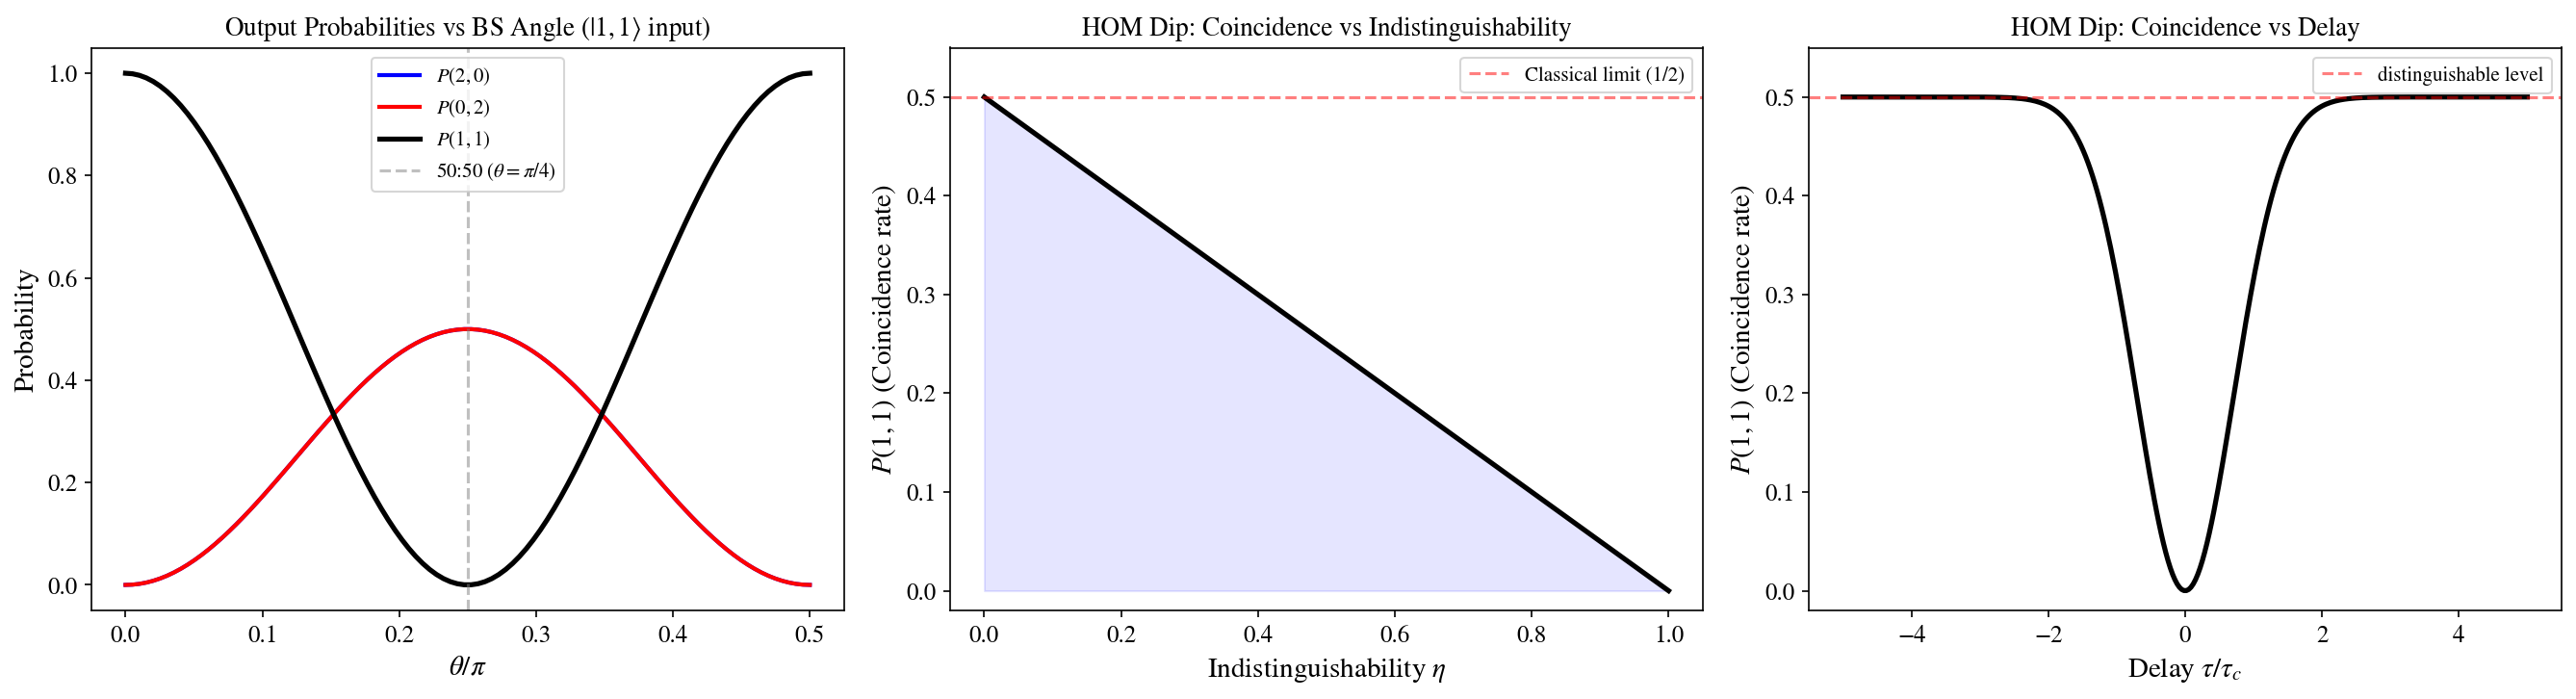

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: P(n1,n2) vs theta for |1,1> input
thetas = np.linspace(0, np.pi/2, 100)
P_20, P_02, P_11_list = [], [], []

for theta in thetas:
    U = beam_splitter(theta, a1, a2)
    out = U * state_11
    P_20.append(abs(qutip.tensor(qutip.basis(N,2), qutip.basis(N,0)).overlap(out))**2)
    P_02.append(abs(qutip.tensor(qutip.basis(N,0), qutip.basis(N,2)).overlap(out))**2)
    P_11_list.append(abs(qutip.tensor(qutip.basis(N,1), qutip.basis(N,1)).overlap(out))**2)

axes[0].plot(thetas/np.pi, P_20, 'b-', linewidth=2, label='$P(2,0)$')
axes[0].plot(thetas/np.pi, P_02, 'r-', linewidth=2, label='$P(0,2)$')
axes[0].plot(thetas/np.pi, P_11_list, 'k-', linewidth=2.5, label='$P(1,1)$')
axes[0].axvline(x=0.25, color='gray', linestyle='--', alpha=0.5, label=r'50:50 ($\theta=\pi/4$)')
axes[0].set_xlabel(r'$\theta/\pi$', fontsize=14)
axes[0].set_ylabel('Probability', fontsize=14)
axes[0].set_title(r'Output Probabilities vs BS Angle ($|1,1\rangle$ input)', fontsize=13)
axes[0].legend(fontsize=10)

# Panel 2: Coincidence dip (HOM dip vs indistinguishability)
eta_vals = np.linspace(0, 1, 100)
P_coinc = (1 - eta_vals) / 2

axes[1].plot(eta_vals, P_coinc, 'k-', linewidth=2.5)
axes[1].fill_between(eta_vals, 0, P_coinc, alpha=0.1, color='blue')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Classical limit (1/2)')
axes[1].set_xlabel(r'Indistinguishability $\eta$', fontsize=14)
axes[1].set_ylabel(r'$P(1,1)$ (Coincidence rate)', fontsize=14)
axes[1].set_title('HOM Dip: Coincidence vs Indistinguishability', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_ylim(-0.02, 0.55)

# Panel 3: Experimental-format HOM dip vs time delay
tau = np.linspace(-5, 5, 300)
eta_tau = np.exp(-tau**2)
P_coinc_tau = 0.5 * (1 - eta_tau)

axes[2].plot(tau, P_coinc_tau, 'k-', linewidth=2.5)
axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='distinguishable level')
axes[2].set_xlabel(r'Delay $\tau/\tau_c$', fontsize=14)
axes[2].set_ylabel(r'$P(1,1)$ (Coincidence rate)', fontsize=14)
axes[2].set_title('HOM Dip: Coincidence vs Delay', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].set_ylim(-0.02, 0.55)

plt.tight_layout()
plt.savefig(FIG_DIR / 'hom_effect_and_dip.png', bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'hom_effect_and_dip.svg', bbox_inches='tight')
plt.show()